In [1]:
import pandas as pd
from sklearn import datasets
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np
import scipy.stats as stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.descriptivestats import sign_test
from statsmodels.stats.contingency_tables import mcnemar
import category_encoders as ce
import statistics as st
import plotly
import plotly.express as px
import plotly.graph_objects as go
import pycountry

# подгружаем данные из файла
df=pd.read_csv('ds_salaries.csv')

# знакомимся с датафреймом
display(df.shape)
display(df.info())
df.head()

(607, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


None

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


Размер ДФ 607 строк, 12 столбцов.
Типы данных: int64(5), object(7)

In [2]:
# прверка на наличие пропусков (достаточно информации из info()).
df.info()
#df.isnull().mean() * 100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


Все строки непустые.

In [3]:
# прверка дублирования строк
print('Количество дубликатов: {}'.format(df[df.duplicated()].shape[0]))
df = df.drop_duplicates()
print('Размер таблицы после удаления дубликатов: {}'.format(df.shape))

Количество дубликатов: 0
Размер таблицы после удаления дубликатов: (607, 12)


In [4]:
# приводим признаки к актуальномым типам данных
df['work_year']=df['work_year'].astype('category')
df['experience_level'] = pd.Categorical(df['experience_level'], ["EN", "MI", "SE", "EX"])
df['employment_type'] = pd.Categorical(df['employment_type'], ["PT", "FT", "CT", "FL"])
df['job_title']=df['job_title'].astype('string')
df['salary_currency']=df['salary_currency'].astype('string')
#df['employee_residence']=df['employee_residence'].astype('string')
df['remote_ratio']=df['remote_ratio'].astype('category')
df['company_size'] = pd.Categorical(df['company_size'], ["S", "M", "L"])
#df['company_location']=df['company_location'].astype('string')

df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Unnamed: 0          607 non-null    int64   
 1   work_year           607 non-null    category
 2   experience_level    607 non-null    category
 3   employment_type     607 non-null    category
 4   job_title           607 non-null    string  
 5   salary              607 non-null    int64   
 6   salary_currency     607 non-null    string  
 7   salary_in_usd       607 non-null    int64   
 8   employee_residence  607 non-null    object  
 9   remote_ratio        607 non-null    category
 10  company_location    607 non-null    object  
 11  company_size        607 non-null    category
dtypes: category(5), int64(3), object(2), string(2)
memory usage: 41.7+ KB


In [5]:
# сразу удалим неинформативный признак "Unnamed: 0", т.к. он дублирует index.
df=df.drop('Unnamed: 0',axis=1)
# и оставим две профессии Data Scientist и Data Engineer
df=df[(df['job_title']=='Data Scientist') | (df['job_title']=='Data Engineer')]
df['job_title'].value_counts()

Data Scientist    143
Data Engineer     132
Name: job_title, dtype: Int64

In [6]:
df=df.drop(['salary', 'salary_currency'],axis=1)

Единственным числовым признаком в исходных данных после удаления неинформативных признаков можно считать признак "salary in USD"

### Распределение уровня заработной платы по всем соискателям

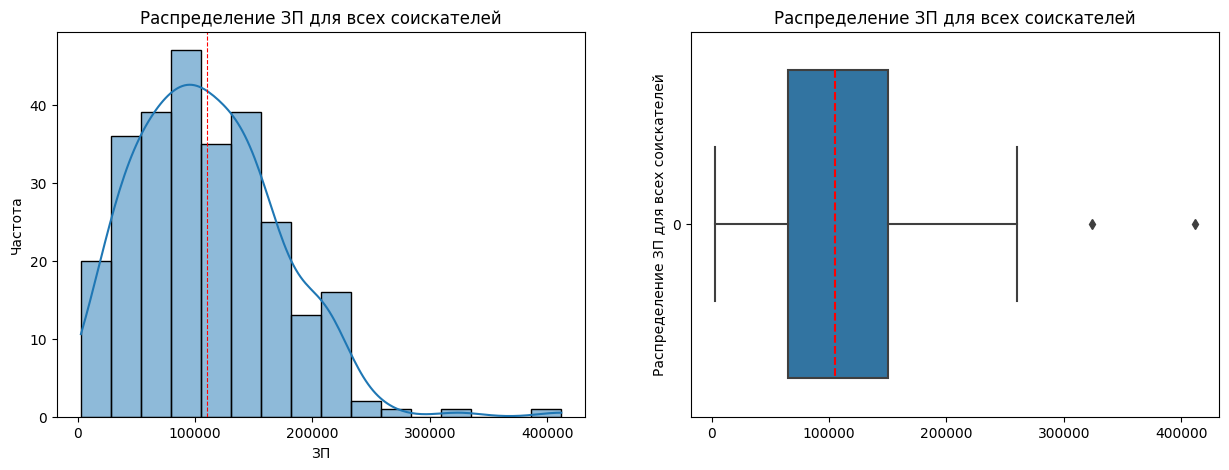

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['salary_in_usd'], kde=True, ax=axes[0])
axes[0].set(xlabel='ЗП', ylabel='Частота')
axes[0].set_title('Распределение ЗП для всех соискателей')
axes[0].axvline(df['salary_in_usd'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(df['salary_in_usd'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='Распределение ЗП для всех соискателей')
axes[1].set_title('Распределение ЗП для всех соискателей')

plt.show()

In [8]:
#основные статистические характеристики для числового признака 'salary_in_usd'
display(df['salary_in_usd'].describe().round().to_frame())
#display('mean meaning',round(st.mean(df['salary_in_usd']),2))
display('mode meaning',round(st.mode(df['salary_in_usd']),2))
display('median meaning',round(st.median(df['salary_in_usd']),2))


,salary_in_usd
count,275.0
mean,110366.0
std,61018.0
min,2859.0
25%,65438.0
50%,104702.0
75%,150000.0
max,412000.0


'mode meaning'

100000

'median meaning'

104702

Распределение уровня заработной платы по всем соискателям отлично от нормального, имеются выбросы.

### Распределение размера ЗП Data Scientist и Data Engineer

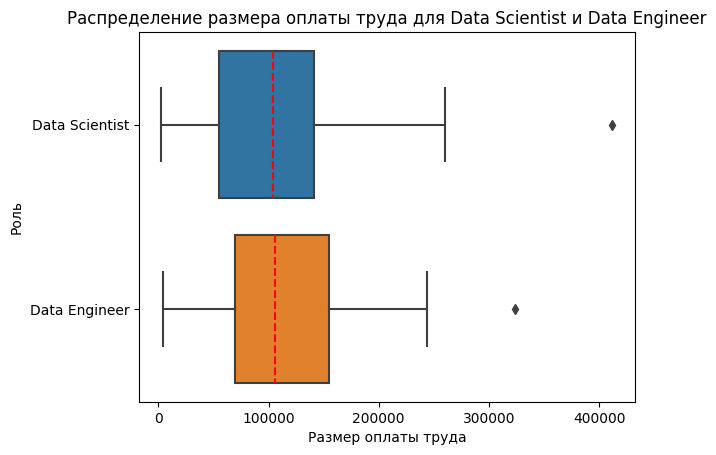

In [9]:
ax = sns.boxplot(df, x='salary_in_usd', y='job_title', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер оплаты труда', ylabel='Роль')
plt.title('Распределение размера оплаты труда для Data Scientist и Data Engineer')
plt.show()

### Зависимость размера ЗП от опыта работы

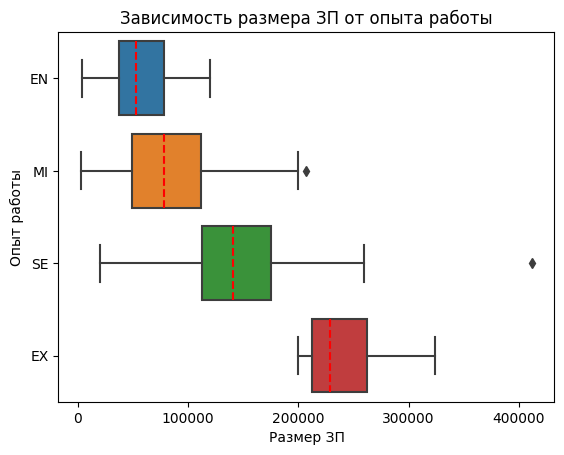

In [10]:
ax = sns.boxplot(df, x='salary_in_usd', y='experience_level', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер ЗП', ylabel='Опыт работы')
plt.title('Зависимость размера ЗП от опыта работы')
plt.show()

In [11]:
df_agg = df.groupby('experience_level')['salary_in_usd'].describe().round(2)
print('Зависимость размера ЗП от опыта работы')
df_agg

Зависимость размера ЗП от опыта работы


,count,mean,std,min,25%,50%,75%,max
experience_level,,,,,,,,
EN,34.0,56602.41,29002.78,4000.0,37461.25,52373.5,78125.0,120000.0
MI,113.0,83890.16,45603.07,2859.0,49461.00,78526.0,111775.0,206699.0
SE,124.0,144874.92,53508.67,20171.0,112375.00,140325.0,175025.0,412000.0
EX,4.0,245500.00,55121.08,200000.0,212000.00,229000.0,262500.0,324000.0


Распределения уровня заработной платы для соискателей с разным опытом работы различны, но прослеживается прямая закономерность "больше опыта-выше ЗП". Чтобы определить, являются ли эти различия статистически значимыми, в следующем разделе мы проведём статистическое тестирование. В категориях Mid-level/Intermediate и Senior-level/Expert есть выбросы.

### Зависимость размера ЗП от вида занятости

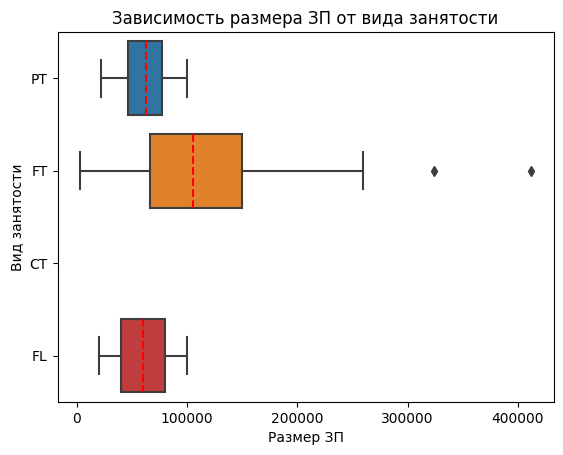

In [12]:
ax = sns.boxplot(df, x='salary_in_usd', y='employment_type', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер ЗП', ylabel='Вид занятости')
plt.title('Зависимость размера ЗП от вида занятости')
plt.show()

In [13]:
df_agg = df.groupby('employment_type')['salary_in_usd'].describe().round(2)
print('Зависимость размера ЗП от вида занятости')
df_agg

Зависимость размера ЗП от вида занятости


,count,mean,std,min,25%,50%,75%,max
employment_type,,,,,,,,
PT,4.0,61591.75,32554.82,21669.0,46635.0,62349.0,77305.75,100000.0
FT,269.0,111465.40,61050.19,2859.0,65949.0,105000.0,150000.00,412000.0
CT,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FL,2.0,60000.00,56568.54,20000.0,40000.0,60000.0,80000.00,100000.0


Распределение уровня заработной платы от вида занятости различны. Для данного распределения прослеживаться закономерность "большее вовлечение-выше ЗП". В категории "полный рабочий день" есть выбросы. Подкатегория "работники по контракту" отсутствует. Чтобы определить, являются ли различия в распределении статистически значимыми, в следующем разделе мы проведём статистическое тестирование.

### Зависимость размера ЗП от объема работы, выполняемой удалённо

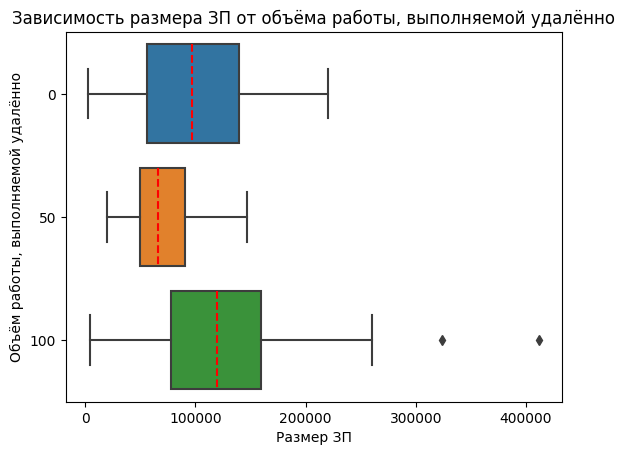

In [14]:
ax = sns.boxplot(df, x='salary_in_usd', y='remote_ratio', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер ЗП', ylabel='Объём работы, выполняемой удалённо')
plt.title('Зависимость размера ЗП от объёма работы, выполняемой удалённо')
plt.show()

In [15]:
df_agg = df.groupby('remote_ratio')['salary_in_usd'].describe().round(2)
print('Зависимость размера ЗП от объёма работы, выполняемой удалённо')
df_agg

Зависимость размера ЗП от объёма работы, выполняемой удалённо


,count,mean,std,min,25%,50%,75%,max
remote_ratio,,,,,,,,
0,66.0,100348.33,56707.51,2859.0,56475.0,96854.0,139300.0,220110.0
50,37.0,71593.70,32600.12,20171.0,49646.0,66022.0,90734.0,147000.0
100,172.0,122550.02,63296.48,4000.0,77739.5,120080.0,160000.0,412000.0


Зависимость размера ЗП от объёма работы, для полностью удаленного формата и для работы в офисе близки по значениям. Для категрии 50%\50% медианный уровень ЗП ниже, чем в остальных категориях. В категории полностью удаленной работы есть выбросы. Чтобы определить, являются ли различия в распределении статистически значимыми, в следующем разделе мы проведём статистическое тестирование.

### Зависимость размера ЗП от компании роботодателя.

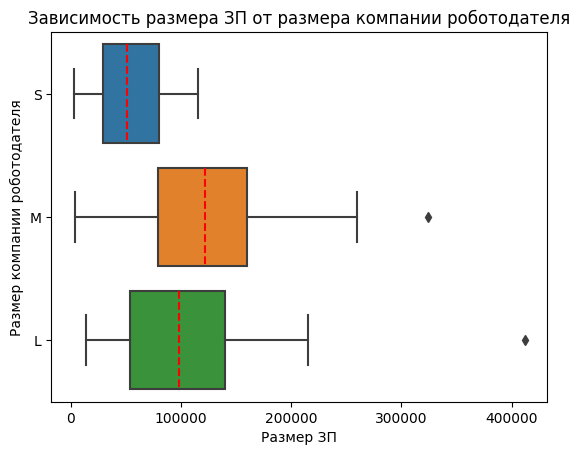

In [16]:
ax = sns.boxplot(df, x='salary_in_usd', y='company_size', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Размер ЗП', ylabel='Размер компании роботодателя')
plt.title('Зависимость размера ЗП от размера компании роботодателя')
plt.show()

In [17]:
df_agg = df.groupby('company_size')['salary_in_usd'].describe().round(2)
print('Зависимость размера ЗП от размера компании роботодателя')
df_agg

Зависимость размера ЗП от размера компании роботодателя


,count,mean,std,min,25%,50%,75%,max
company_size,,,,,,,,
S,27.0,55129.48,32345.24,2859.0,29521.5,51321.0,79729.0,115000.0
M,166.0,122623.45,57276.05,4000.0,78894.5,121580.0,160000.0,324000.0
L,82.0,103738.68,64859.83,13400.0,53579.5,98141.0,140300.0,412000.0


Зависимость размера ЗП от размера компании роботодателя(штата сотрудников) распределена неравномерно. Максимальное значения медианной ЗП просматривается у организаций средного масштаба. Для крупных работодателей есть выбросы по предлагаемой ЗП. Чтобы определить, являются ли эти различия статистически значимыми, в следующем разделе мы проведём статистическое тестирование.

### Зависимость размера ЗП от местонахождения компании роботодателя и зависимость размера ЗП от местонахождения соискателя.

In [18]:
print(df['employee_residence'].nunique())# смотрим кол-во уникальных значений
#создаем список тринадцати часто встречающихся стран
top_countries=df['employee_residence'].value_counts().nlargest(n=13).to_dict()
top_countries=top_countries.keys()

#df['experience_level'] = pd.Categorical(df['employee_residence'], top_countries)

#оставляем значимые страны остальные относим к other
df['employee_residence']=df['employee_residence'].apply(lambda x: x if x in top_countries else 'Other')


33


In [19]:
#тоже самое делаем для company_location
print(df['company_location'].nunique())# смотрим кол-во уникальных значений
#создаем список тринадцати часто встречающихся стран
top_countries=df['company_location'].value_counts().nlargest(n=13).to_dict()
top_countries=top_countries.keys()

#оставляем значимые страны остальные относим к other
df['company_location']=df['company_location'].apply(lambda x: x if x in top_countries else 'Other')

29


Text(0.5, 1.0, 'Распределение ЗП от места проживания соискателей')

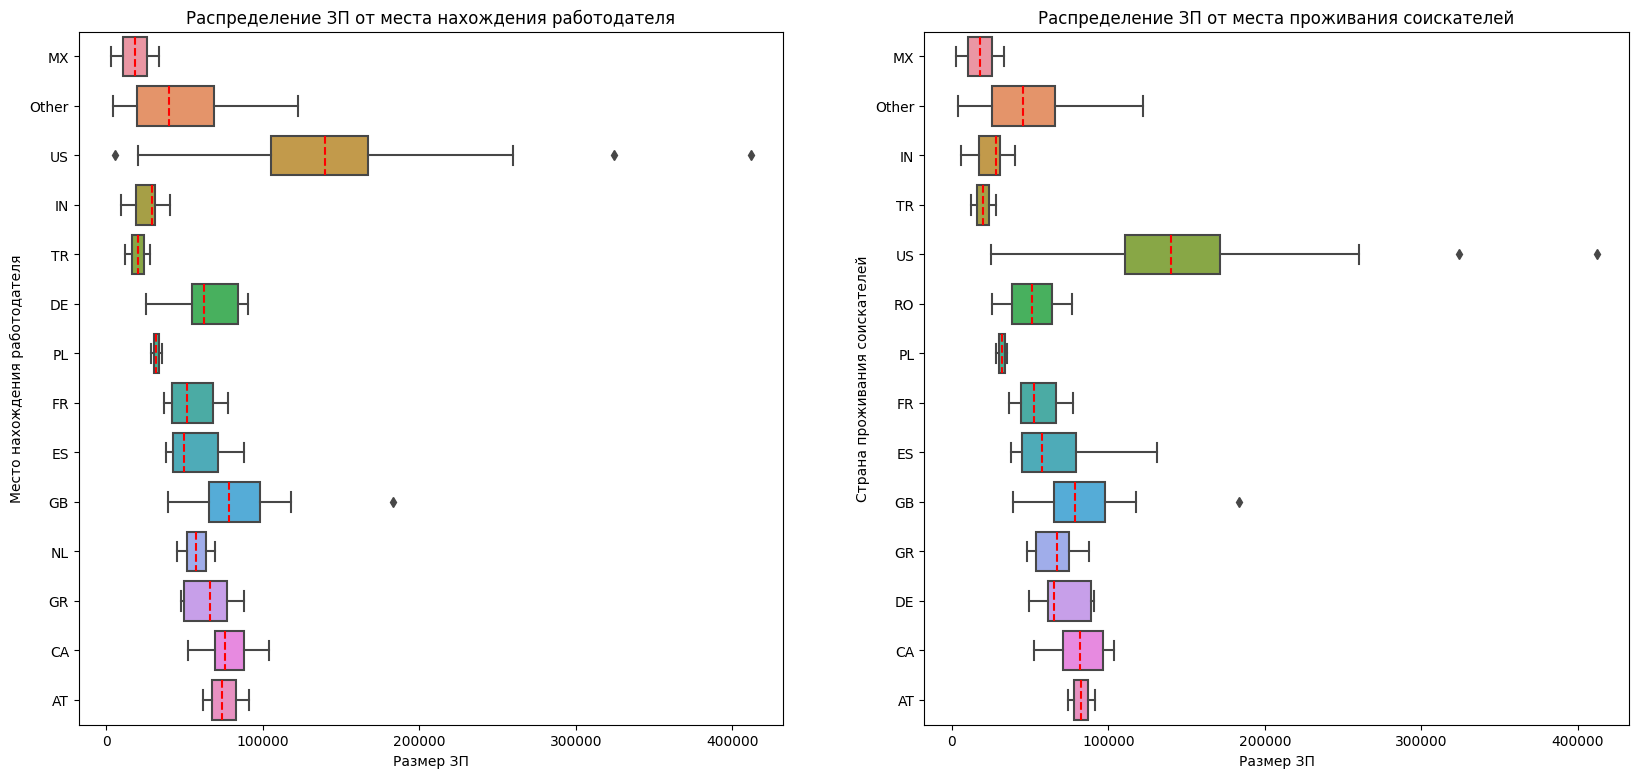

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

sns.boxplot(df.sort_values(by = 'salary_in_usd'), x='salary_in_usd', y= 'company_location', ax=axes[0], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[0].set(xlabel='Размер ЗП', ylabel='Место нахождения работодателя')
axes[0].set_title('Распределение ЗП от места нахождения работодателя')

sns.boxplot(df.sort_values(by = 'salary_in_usd'), x='salary_in_usd', y='employee_residence', ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(xlabel='Размер ЗП', ylabel='Страна проживания соискателей')
axes[1].set_title('Распределение ЗП от места проживания соискателей')

Основываясь на графиках выше, можно сделать следующие выводы:
- максимальный разброс по ЗП наблюдается у компаний лоцированных в США;
- максимальный разброс по ожиданиям ЗП наблюдается соискателей также из США;
- максимальный уровень ЗП на старте ожидают соискатели из Австрии;
- максимальный уровень ЗП на старте предлагают работодатели также из Австрии;
- максимальное медианное значение ЗП у соискателей и работодателей наблюдается в США.

## Статистический анализ данных

In [21]:
# задаём уровень значимости
alpha = 0.05 
print("Уровень значимости alpha = {:.2f}".format(alpha))

Уровень значимости alpha = 0.05


In [22]:
# функция для принятия решения о нормальности
def decision_normality(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Распределение отлично от нормального'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. Распределение является нормальным'.format(alpha))


# функция для принятия решения об отклонении нулевой гипотезы
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу в пользу альтернативной.'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

### Размер заработной платы для Data Engineer больше, чем для Data Scientist??

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): размер заработной платы Data Engineer ($μ_1$) статистически меньше либо равен размеру страховых выплат Data Scientist ($μ_2$).

$$ H_0 : μ_1 <= μ_2$$

*Альтернативная гипотеза* ($H_1$): размер страховых выплат Data Engineer ($μ_1$) статистически больше, чем размер страховых выплат Data Scientist ($μ_2$).

$$ H_1 : μ_1 > μ_2$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально. Напомним гипотезы теста Шапиро-Уилка:

*Нулевая гипотеза* ($H_0$): распределение данные является нормальным.

*Альтернативная гипотеза* ($H_1$): распределение данных отлично от нормального.

In [23]:
# значения заработной платы
Data_Engineer = df.loc[df['job_title']=='Data Engineer', 'salary_in_usd']
Data_Scientist = df.loc[df['job_title']=='Data Scientist', 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Для Data Engineer:')
result = stats.shapiro(Data_Engineer)
decision_normality(result[1])

print('Для Data Scientist:')
result = stats.shapiro(Data_Scientist)
decision_normality(result[1])

Для Data Engineer:
p-value = 0.010
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для Data Scientist:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Размер заработной платы»? — Количественный.
* Сколько сравниваемых групп? — Две.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет.

Чтобы проверить нашу гипотезу, можно использовать U-критерий Манна — Уитни для сравнения распределений на основе рангов.

**Проведём тест**

In [24]:
# проводим тест
_, p = stats.mannwhitneyu(Data_Engineer, Data_Scientist, alternative='greater')
decision_hypothesis(p)

p-value = 0.234
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


**Вывод**

Нет оснований утверждать, что размер оплаты труда для Data Engineer больше, чем для Data Scientist.

### Влияет ли опыт работы на размер ЗП?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: размер ЗП не отличается от опыта работы: EN ($μ_1$), MI ($μ_2$), SE ($μ_3$), EX ($μ_4$).

$$ H_0 : μ_1 = μ_2 = μ_3 = μ_4$$

*Альтернативная гипотеза*: размер ЗП отличается от опыта работы: EN ($μ_1$), MI ($μ_2$), SE ($μ_3$), EX ($μ_4$).

$$ H_1 : μ_1 \neq μ_2 \neq μ_3 \neq μ_4$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [25]:
# значения ЗП
charges_en = df.loc[df['experience_level']=='EN', 'salary_in_usd']
charges_mi = df.loc[df['experience_level']=='MI', 'salary_in_usd']
charges_se = df.loc[df['experience_level']=='SE', 'salary_in_usd']
charges_ex = df.loc[df['experience_level']=='EX', 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Для EN:')
result = stats.shapiro(charges_en)
decision_normality(result[1])

print('Для MI:')
result = stats.shapiro(charges_mi)
decision_normality(result[1])

print('Для SE:')
result = stats.shapiro(charges_se)
decision_normality(result[1])

print('Для EX:')
result = stats.shapiro(charges_ex)
decision_normality(result[1])

Для EN:
p-value = 0.557
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Для MI:
p-value = 0.020
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для SE:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для EX:
p-value = 0.337
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Experience_level»? — Количественный.
* Сколько сравниваемых групп? — Четыре.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет. 

Для проверки нашей гипотезы можно использовать критерий Краскела — Уоллиса.

**Проведём тест**

In [26]:
# проводим тест
_, p = stats.kruskal(charges_en, charges_mi, charges_se, charges_ex)
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

У нас есть основание утверждать, что размер оплаты труда для Data Engineer больше, чем для Data Scientist в зависимости от опыта соискателя.